# Turning a window into a picture: GAF and MTF encodings

**Docker image**: `ml4t-gpu`

Every architecture in this section so far has kept the window as a sequence and
argued about how to relate its positions - attention, dilated convolution, mixing,
a recurrent state. This notebook takes a different route: it turns each window into
a two-channel image and hands it to an ordinary image CNN, so that the whole
apparatus built for pictures applies unchanged.

The encodings are the point. A **Gramian angular field** rescales the window to
$[-1, 1]$, reads each value as an angle, and fills cell $(i, j)$ with a function of
the two angles - so the image is a table of every pair of positions, and a
convolution over it reads relations between pairs rather than between values. A
**Markov transition field** bins the window into quantiles and fills cell $(i, j)$
with how often the series moved between the bins those two positions fall in.

What the transformation discards is as important as what it builds, and both
encodings below discard the same thing: they normalise inside each window, so the
level and the range of the returns are gone before the CNN sees anything. Two
windows of the same shape and different volatility become the same picture.

**Learning objectives**:
- Build both encodings from the definition and say what each cell of the resulting
  matrix means.
- Say what the per-window normalisation throws away, and why that matters for a
  label whose scale is a return.
- Read the resampling step: a `LOOKBACK`-day window becomes an
  `IMAGE_SIZE`-by-`IMAGE_SIZE` image, so check whether that interpolates up or
  summarises down before treating pixels as data.
- Score the CNN against a penalised linear map on the same flattened pixels, so the
  comparison isolates the CNN and not the encoding.

**Book Reference**: Chapter 13, Section 13.6 (Alternative architectures and foundation models)

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""CNN with Time Series Image Encoding - convert time series to GAF/MTF images for forward-return regression."""

import os

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
from dl_sequences import create_sequences_multi_asset, load_dl_dataset, train_model
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, show_plotly_with_alt, show_with_alt

In [2]:
SEED = 42
LOOKBACK = 20
IMAGE_SIZE = 32
EPOCHS = 10
BATCH_SIZE = 64
LR = 1e-4
DROPOUT = 0.5
MAX_TRAIN_SAMPLES = 40_000
MAX_VAL_SAMPLES = 10_000
MAX_TEST_SAMPLES = 10_000
INFER_BATCH_SIZE = 1_024
LABEL_HORIZON = 21

In [3]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

Device: cuda


## Data Loading

We use the five-day ETF return from the case-study pipeline. Both models see
exactly the same one-feature windows.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = ["ret_5d"]
TARGET_COL = mds.label_col

missing_features = sorted(set(FEATURE_COLS) - set(mds.feature_names))
if missing_features:
    raise ValueError(f"Missing required ETF return features: {missing_features}")

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

Loaded etfs: 402,526 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (1): ['ret_5d']
Target: fwd_ret_21d


## Sequence Creation and Temporal Split

In [5]:
df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Rows after dropping nulls: {len(df):,}")
per_date = df.group_by(mds.date_col).len().sort(mds.date_col)
print(
    f"{df[mds.date_col].min()} to {df[mds.date_col].max()}, "
    f"{df[mds.entity_cols[0]].n_unique()} funds; funds per date "
    f"{per_date['len'].min()} to {per_date['len'].max()}, median {per_date['len'].median():.0f}"
)
print(
    f"Label {TARGET_COL}: mean {df[TARGET_COL].mean():+.5f}, "
    f"standard deviation {df[TARGET_COL].std():.5f}"
)

X, y, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
print(f"Sequences: {X.shape[0]:,}, shape: {X.shape}")

sequence_order = np.lexsort((symbols.astype(str), timestamps))
X = np.nan_to_num(X[sequence_order], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y = np.nan_to_num(y[sequence_order], nan=0.0).astype(np.float32)
timestamps = timestamps[sequence_order]
symbols = symbols[sequence_order]

Rows after dropping nulls: 402,526
2007-01-03 to 2025-12-01, 99 funds; funds per date 47 to 96, median 90
Label fwd_ret_21d: mean +0.00693, standard deviation 0.06028


Sequences: 400,546, shape: (400546, 20, 1)


### Splitting by date, with a gap for the label horizon

The split is by date, at fixed fractions of the trading days, and an example belongs
to the partition the date it carries falls in. The label is a `LABEL_HORIZON`-day
forward return, so an example dated within that many days of a boundary has an
outcome resolved by days on the far side; those examples are dropped. Input windows
may still reach back over a boundary, which is right - at decision time the model has
every past observation available.

In [6]:
unique_dates = np.sort(np.unique(timestamps))
train_boundary_idx = int(len(unique_dates) * 0.6)
val_boundary_idx = int(len(unique_dates) * 0.8)
train_end_date = unique_dates[train_boundary_idx]
val_end_date = unique_dates[val_boundary_idx]
train_label_cutoff = unique_dates[train_boundary_idx - LABEL_HORIZON]
val_label_cutoff = unique_dates[val_boundary_idx - LABEL_HORIZON]

train_mask = timestamps < train_label_cutoff
val_mask = (timestamps >= train_end_date) & (timestamps < val_label_cutoff)
test_mask = timestamps >= val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(
    f"Purged {LABEL_HORIZON} target dates before each boundary before complete-date subsampling: "
    f"validation starts {train_end_date}, test starts {val_end_date}"
)

Train: 218,504, Val: 88,454, Test: 89,577
Purged 21 target dates before each boundary before complete-date subsampling: validation starts 2018-05-17, test starts 2022-02-22


### Pedagogical subsampling

The GAF/MTF encoding loop produces one (image_size x image_size x 2) tensor
per sample, so the full ETF panel takes considerable wall-clock to encode.
We cap each split at a few tens of thousands of sequences for tractable
runtime. Critically we subsample by **complete dates**, not row count: the
sequence array can begin or end partway through a date, so a raw row slice
would leave a partial cross-section. Keeping the most recent complete dates
instead gives a stable, full cross-section that reproduces across runs.

In [7]:
def _trim_by_complete_dates(X_arr, y_arr, ts_arr, sym_arr, max_samples):
    """Keep the most recent whole dates whose total rows fit under `max_samples`."""
    if len(X_arr) <= max_samples:
        return X_arr, y_arr, ts_arr, sym_arr
    unique_ts = np.sort(np.unique(ts_arr))[::-1]
    cumulative = 0
    keep_dates: list = []
    for ts in unique_ts:
        n = int((ts_arr == ts).sum())
        if cumulative + n > max_samples and keep_dates:
            break
        cumulative += n
        keep_dates.append(ts)
    keep_mask = np.isin(ts_arr, np.array(keep_dates))
    return X_arr[keep_mask], y_arr[keep_mask], ts_arr[keep_mask], sym_arr[keep_mask]


X_train, y_train, _train_ts, _train_sym = _trim_by_complete_dates(
    X_train, y_train, timestamps[train_mask], symbols[train_mask], MAX_TRAIN_SAMPLES
)
X_val, y_val, _val_ts, _val_sym = _trim_by_complete_dates(
    X_val, y_val, timestamps[val_mask], symbols[val_mask], MAX_VAL_SAMPLES
)
X_test, y_test, test_dates, test_symbols = _trim_by_complete_dates(
    X_test, y_test, test_dates, test_symbols, MAX_TEST_SAMPLES
)

print(f"Capped split: Train={len(X_train):,}, Val={len(X_val):,}, Test={len(X_test):,}")

Capped split: Train=39,973, Val=9,975, Test=9,964


### Cross-sectional IC helper

Mean cross-sectional Spearman IC by date - the same metric used across this section,
so the image CNN is scored the way the sequence models were.

A date's IC is undefined when a model predicts the same value for every fund on it:
the predicted ranks are all tied and there is nothing to correlate. The library
returns `NaN` for such a date, and polars treats `NaN` and null as different values,
so `drop_nulls` alone leaves it in place and one of them makes the whole mean `NaN`.
Both are filtered here, and the count of dates the mean was taken over is printed
beside it - which matters here, because the subsampling above leaves far fewer dates
than the notebooks that score on the full panel.

In [8]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC over the dates where it is defined.

    Returns the mean and the defined/total date counts. Filters both null and NaN,
    since polars `drop_nulls` leaves NaN in place.
    """
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    defined = ic_per_date.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan())
    mean_ic = float(defined["ic"].mean()) if defined.height else float("nan")
    return {"ic": mean_ic, "n_defined": defined.height, "n_total": ic_per_date.height}

## Gramian Angular Summation Field (GASF)

The GASF encodes a time series as a matrix of trigonometric sums. Given a
normalized series $\tilde{x}_i \in [-1, 1]$, we compute angles
$\phi_i = \arccos(\tilde{x}_i)$ and form:

$$\text{GASF}_{i,j} = \cos(\phi_i + \phi_j)$$

This preserves temporal ordering. The diagonal evaluates to
$\cos(2\phi_i) = 2\tilde{x}_i^2 - 1$ - a deterministic function of the
normalized value, not the value itself - while off-diagonal entries capture
pairwise angular relationships between time steps $i$ and $j$.

In [9]:
def gramian_angular_field(series: np.ndarray, image_size: int) -> np.ndarray:
    """Compute the Gramian Angular Summation Field (GASF).

    Args:
        series: 1D array of shape (T,) -- raw feature values for one window
        image_size: Output image dimension (image_size x image_size)

    Returns:
        GASF matrix of shape (image_size, image_size) with values in [-1, 1]
    """
    # Resample to image_size via linear interpolation
    target_positions = np.linspace(0, len(series) - 1, image_size)
    source_positions = np.arange(len(series))
    resampled = np.interp(target_positions, source_positions, series)

    # Min-max scale to [-1, 1]
    s_min, s_max = resampled.min(), resampled.max()
    if s_max - s_min < 1e-8:
        return np.zeros((image_size, image_size), dtype=np.float32)
    scaled = 2.0 * (resampled - s_min) / (s_max - s_min) - 1.0
    scaled = np.clip(scaled, -1.0, 1.0)

    # Compute angular representation
    phi = np.arccos(scaled)

    # GASF: cos(phi_i + phi_j)
    gasf = np.cos(phi[:, None] + phi[None, :])
    return gasf.astype(np.float32)

## Markov Transition Field (MTF)

The MTF discretizes a time series into $Q$ quantile bins and builds a
transition matrix $W$ where $W_{q_i, q_j}$ is the probability of
transitioning from bin $q_i$ to bin $q_j$. The full MTF matrix is:

$$\text{MTF}_{i,j} = W_{q_i, q_j}$$

where $q_i$ is the quantile bin of the $i$-th timestep. This captures the
dynamic transition structure of the series.

In [10]:
def markov_transition_field(series: np.ndarray, image_size: int, n_bins: int = 8) -> np.ndarray:
    """Compute the Markov Transition Field (MTF).

    Args:
        series: 1D array of shape (T,) -- raw feature values for one window
        image_size: Output image dimension (image_size x image_size)
        n_bins: Number of quantile bins for discretization

    Returns:
        MTF matrix of shape (image_size, image_size) with values in [0, 1]
    """
    # Resample to image_size via linear interpolation
    target_positions = np.linspace(0, len(series) - 1, image_size)
    source_positions = np.arange(len(series))
    resampled = np.interp(target_positions, source_positions, series)

    # Discretize into quantile bins
    bin_edges = np.percentile(resampled, np.linspace(0, 100, n_bins + 1))
    bin_edges[-1] += 1e-8  # ensure max value is included
    bin_ids = np.digitize(resampled, bin_edges[1:-1])

    # Build transition matrix (n_bins x n_bins)
    transition = np.zeros((n_bins, n_bins), dtype=np.float32)
    for t in range(len(bin_ids) - 1):
        transition[bin_ids[t], bin_ids[t + 1]] += 1

    # Normalize rows to get probabilities
    row_sums = transition.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    transition /= row_sums

    # Build MTF: entry (i, j) = transition probability from bin at time i to bin at time j
    # Vectorized via advanced indexing (equivalent to the nested loop but ~100x faster)
    mtf = transition[np.ix_(bin_ids, bin_ids)]

    return mtf.astype(np.float32)

## Create Multi-Channel Image Dataset

For each one-feature sequence, we encode the return history as a GASF and an MTF,
then stack them as a 2-channel image. This gives the CNN both angular
structure (GASF) and transition dynamics (MTF) as complementary views.

> **Simplification**: This demo encodes only the five-day return history. A production
> system would encode all features, stacking GASF+MTF per feature to produce a
> $(2 \times F)$-channel image. We use one
> feature here to keep encoding time manageable and focus on the method itself.

In [11]:
def create_image_dataset(X_sequences: np.ndarray, image_size: int) -> np.ndarray:
    """Convert feature sequences into stacked GAF + MTF image tensors.

    For each sample, takes the return feature and computes both GASF
    and MTF encodings, returning a (N, 2, H, W) tensor.

    Args:
        X_sequences: Array of shape (N, lookback, n_features)
        image_size: Target image dimension (H = W = image_size)

    Returns:
        Image tensor of shape (N, 2, image_size, image_size)
    """
    n_samples = X_sequences.shape[0]
    images = np.zeros((n_samples, 2, image_size, image_size), dtype=np.float32)

    for i in range(n_samples):
        series = X_sequences[i, :, 0]
        images[i, 0] = gramian_angular_field(series, image_size)
        images[i, 1] = markov_transition_field(series, image_size)

        if (i + 1) % 10000 == 0 or i == n_samples - 1:
            print(f"  Encoded {i + 1:,}/{n_samples:,} samples")

    return images

## Encode Training, Validation, and Test Sets

In [12]:
print("Encoding training images...")
X_train_img = create_image_dataset(X_train, IMAGE_SIZE)
print(f"Train images: {X_train_img.shape}")

print("Encoding validation images...")
X_val_img = create_image_dataset(X_val, IMAGE_SIZE)
print(f"Val images: {X_val_img.shape}")

print("Encoding test images...")
X_test_img = create_image_dataset(X_test, IMAGE_SIZE)
print(f"Test images: {X_test_img.shape}")

Encoding training images...


  Encoded 10,000/39,973 samples


  Encoded 20,000/39,973 samples


  Encoded 30,000/39,973 samples


  Encoded 39,973/39,973 samples
Train images: (39973, 2, 32, 32)
Encoding validation images...


  Encoded 9,975/9,975 samples
Val images: (9975, 2, 32, 32)
Encoding test images...


  Encoded 9,964/9,964 samples
Test images: (9964, 2, 32, 32)


## Visualize Sample Encodings

Inspecting the GASF and MTF channels for a few training samples to verify
the encoding produces visually distinct patterns.

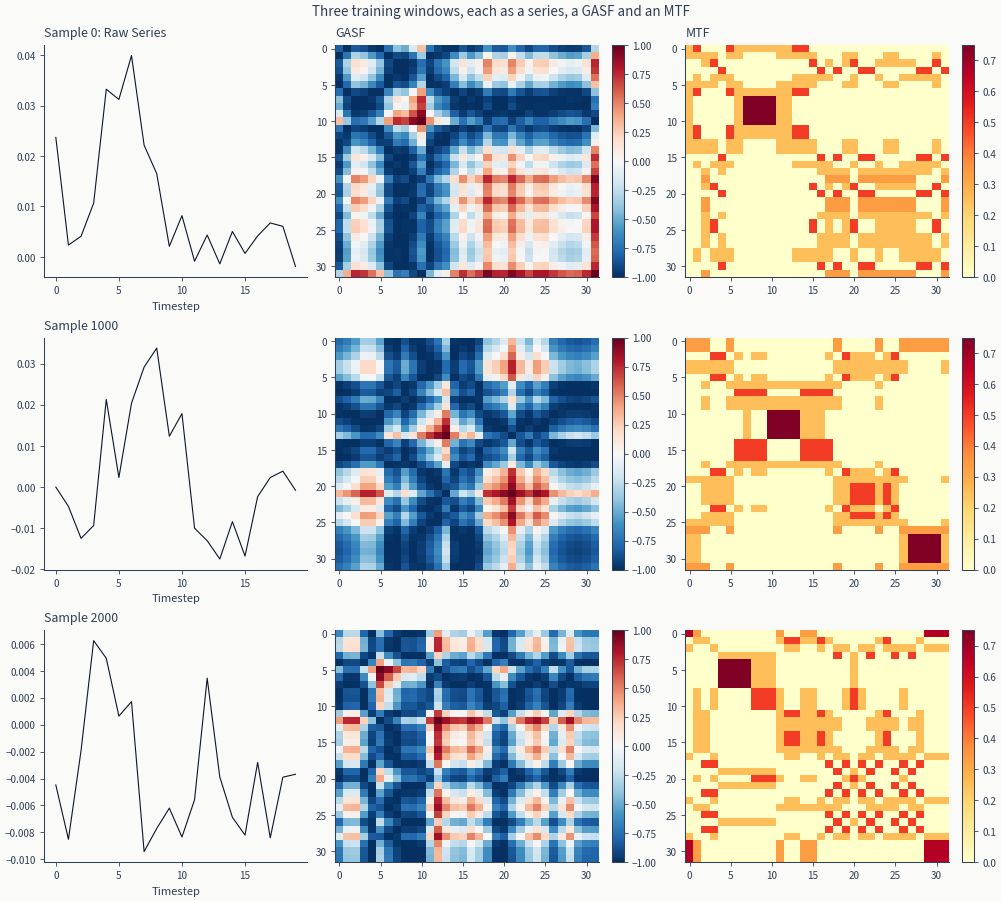

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(10, 9), constrained_layout=True)

for row in range(3):
    idx = row * 1000  # spread samples across the dataset
    if idx >= len(X_train_img):
        idx = row

    # Raw feature series
    axes[row, 0].plot(X_train[idx, :, 0], linewidth=0.8)
    axes[row, 0].set_title(f"Sample {idx}: Raw Series" if row == 0 else f"Sample {idx}")
    axes[row, 0].set_xlabel("Timestep")

    # GASF channel
    im1 = axes[row, 1].imshow(X_train_img[idx, 0], cmap="RdBu_r", aspect="auto")
    axes[row, 1].set_title("GASF" if row == 0 else "")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    # MTF channel
    im2 = axes[row, 2].imshow(X_train_img[idx, 1], cmap="YlOrRd", aspect="auto")
    axes[row, 2].set_title("MTF" if row == 0 else "")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

fig.suptitle("Three training windows, each as a series, a GASF and an MTF")
show_with_alt(
    fig,
    "A three-by-three grid, one row per training window. The left panel of each row "
    "plots the window as a line against timestep; the middle shows its GASF matrix on "
    "a blue-to-red diverging scale from minus one to one; the right shows its MTF "
    "matrix on a yellow-to-red scale from zero. Both matrices are square with one row "
    "and column per resampled position, and each carries its own colour bar.",
)

## CNN Architecture

Three convolutional blocks (Conv2d $\to$ BatchNorm $\to$ ReLU $\to$ MaxPool)
followed by adaptive average pooling and a linear regression head.
The architecture is intentionally simple to isolate the contribution of
the image encoding from the model complexity.

In [14]:
class CNNBlock(nn.Module):
    """Single CNN building block: Conv2d -> BatchNorm -> ReLU -> MaxPool."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, kernel_size=kernel_size, padding=kernel_size // 2
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

### Full Image CNN

Three CNN blocks downsample the spatial dimensions by $2\times$ each,
followed by adaptive average pooling to a fixed-size vector regardless
of the input image size. Dropout before the final linear layer provides
regularization.

In [15]:
class ImageCNN(nn.Module):
    """CNN for regression on GAF+MTF encoded time series images.

    Architecture:
        Input (N, 2, H, W)
        -> CNNBlock(2, 32)   -> (N, 32, H/2, W/2)
        -> CNNBlock(32, 64)  -> (N, 64, H/4, W/4)
        -> CNNBlock(64, 128) -> (N, 128, H/8, W/8)
        -> AdaptiveAvgPool2d(1, 1) -> (N, 128)
        -> Dropout -> Linear -> (N, 1)
    """

    def __init__(self, n_channels: int = 2, dropout: float = 0.5):
        super().__init__()
        self.block1 = CNNBlock(n_channels, 32)
        self.block2 = CNNBlock(32, 64)
        self.block3 = CNNBlock(64, 128)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)  # flatten to (N, 128)
        x = self.dropout(x)
        return self.fc(x).squeeze(-1)  # (N,)

## Train the Image CNN

In [16]:
set_global_seeds(SEED)
model = ImageCNN(n_channels=2, dropout=DROPOUT).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"ImageCNN parameters: {n_params:,}")
print(
    f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE}, channels: 2 (GASF + MTF), "
    f"from a {LOOKBACK}-day window: {'interpolated up' if IMAGE_SIZE > LOOKBACK else 'summarised down'}"
)

history = train_model(model, X_train_img, y_train, X_val_img, y_val, EPOCHS, LR, BATCH_SIZE, DEVICE)

ImageCNN parameters: 93,537
Image size: 32x32, channels: 2 (GASF + MTF), from a 20-day window: interpolated up


  Epoch 1/10: val_loss=0.003024


  Epoch 5/10: val_loss=0.003006


  Epoch 10/10: val_loss=0.002968


### Training convergence

The two curves are what separates learning from memorising: a training curve alone
cannot tell them apart, because both look like progress. A validation curve that
stays flat or turns up while the training curve keeps falling says the CNN is fitting
something in these images that does not carry to the next stretch of dates.

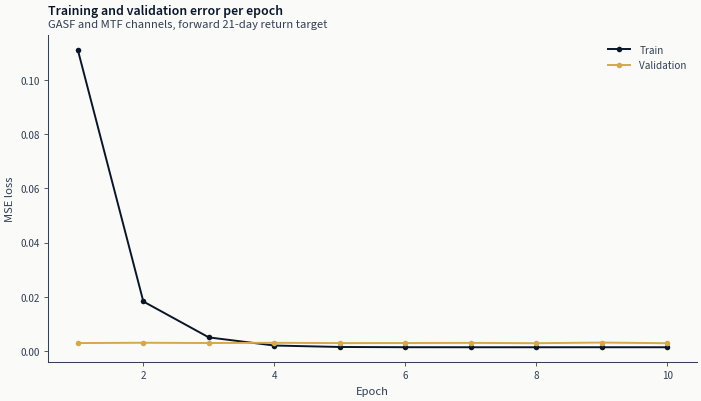

In [17]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
epochs_axis = range(1, len(history["train_loss"]) + 1)
ax.plot(epochs_axis, history["train_loss"], marker="o", color=COLORS["blue"], label="Train")
ax.plot(epochs_axis, history["val_loss"], marker="o", color=COLORS["amber"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.legend()
add_message_title(
    ax,
    "Training and validation error per epoch",
    subtitle="GASF and MTF channels, forward 21-day return target",
)
show_with_alt(
    fig,
    "A line chart of mean squared error against epoch, with one line for the training "
    "set and one for the validation set, marked at each epoch.",
)

## Evaluate on Test Set

In [18]:
model.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_img), INFER_BATCH_SIZE):
        X_test_t = torch.FloatTensor(X_test_img[i : i + INFER_BATCH_SIZE]).to(DEVICE)
        preds.append(model(X_test_t).cpu().numpy())
    y_pred = np.concatenate(preds, axis=0)

test_mse = np.mean((y_pred - y_test) ** 2)
cnn_ic = cross_sectional_ic_mean(y_test, y_pred, test_dates, test_symbols)
test_ic = cnn_ic["ic"]

print("\nImage CNN Test Results:")
print(f"  MSE: {test_mse:.6f}")
print(f"  Spearman IC: {test_ic:.4f}", end="")
print(f"  (defined on {cnn_ic['n_defined']} of {cnn_ic['n_total']} test dates)")


Image CNN Test Results:
  MSE: 0.002025
  Spearman IC: 0.0026  (defined on 106 of 106 test dates)


## Ridge + PCA Baseline

Flatten the 2-channel images into vectors, reduce dimensionality with PCA
(100 components), then fit a Ridge regression. This tests whether the CNN
learns spatial structure beyond what a linear model can extract from the
same pixel representation.

In [19]:
X_train_flat = X_train_img.reshape(len(X_train_img), -1)
X_test_flat = X_test_img.reshape(len(X_test_img), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

n_components = min(100, X_train_scaled.shape[1], X_train_scaled.shape[0])
pca = PCA(n_components=n_components, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_pca, y_train)
y_ridge_pred = ridge.predict(X_test_pca)

ridge_mse = np.mean((y_ridge_pred - y_test) ** 2)
ridge_ic_result = cross_sectional_ic_mean(y_test, y_ridge_pred, test_dates, test_symbols)
ridge_ic = ridge_ic_result["ic"]
zero_mse = float(np.mean(y_test**2))

print(f"\nRidge + PCA ({n_components} components) Baseline:")
print(f"  MSE: {ridge_mse:.6f}")
print(f"  Spearman IC: {ridge_ic:.4f}", end="")
print(f"  (defined on {ridge_ic_result['n_defined']} of {ridge_ic_result['n_total']} test dates)")


Ridge + PCA (100 components) Baseline:
  MSE: 0.001922
  Spearman IC: -0.0069  (defined on 106 of 106 test dates)


## The image CNN against the linear baseline

Two questions, two panels. The left asks whether the model ordered the funds usefully
on each date; the right asks whether its predicted return levels were closer than
predicting zero. A model can do better on one and worse on the other, and both are
reported because acting on a forecast uses the ordering while fitting one minimises
the squared error.

The baseline starts from the *same pixels*, reduces them to `n_components` principal
components and maps those linearly to the label. Holding the encoding fixed on both
sides is what makes the two comparable at all, but it does not isolate convolution:
the two pipelines also differ in how many inputs they see, in whether the map is
linear, and in how each is fitted and penalised. Read the bars as two pipelines
built on one encoding, not as a measurement of what convolution contributed.

Neither bar says anything about whether the encoding itself was worth doing. That
would need a model fitted on the raw window, which the earlier notebooks in this
section supply.

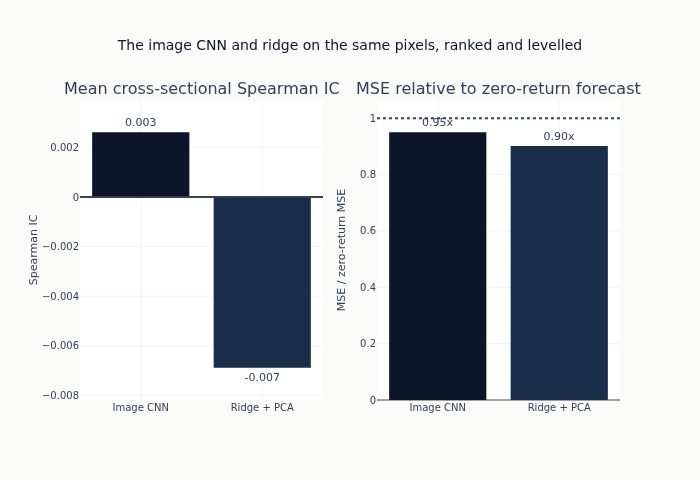

In [20]:
model_names = ["Image CNN", "Ridge + PCA"]
ic_values = [test_ic, ridge_ic]
mse_ratios = [test_mse / zero_mse, ridge_mse / zero_mse]
bar_palette = {"Image CNN": COLORS["blue"], "Ridge + PCA": COLORS["slate"]}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Mean cross-sectional Spearman IC", "MSE relative to zero-return forecast"),
)
for model_name, ic_value, mse_ratio in zip(model_names, ic_values, mse_ratios, strict=True):
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[ic_value],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{ic_value:.3f}"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[mse_ratio],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{mse_ratio:.2f}x"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=2,
    )

fig.add_hline(y=0, line_color=COLORS["neutral"], row=1, col=1)
fig.add_hline(y=1, line_dash="dot", line_color=COLORS["neutral"], row=1, col=2)
fig.update_layout(
    title="The image CNN and ridge on the same pixels, ranked and levelled",
    height=480,
)
fig.update_yaxes(title_text="Spearman IC", row=1, col=1)
fig.update_yaxes(title_text="MSE / zero-return MSE", row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two bar panels, one bar per model. The left panel gives each model's mean "
    "cross-sectional Spearman IC against a line at zero; the right gives its test MSE "
    "as a multiple of the zero forecast's, against a dotted line at one.",
)

## What this setup can and cannot be asked

The input here is one feature - `FEATURE_COLS` holds a single column - where every
other architecture in this section reads eight. That is not an oversight to correct
later; it is what keeps the encoding legible, since a GASF of one series is a
picture you can look at and a GASF of eight is a stack you cannot. It also means the
bars above compare two models on a deliberately thin representation.

The sample is capped the same way `07_mamba_ssm` caps it, so both scores are averaged
over the printed number of dates rather than the whole test stretch. Between the
single feature and the capped dates, this notebook is a demonstration of the
encoding, and the published comparisons that encode every feature and score against
sequence-native models are the tests that would say something about GAF and MTF as a
representation.

## Key takeaways

1. **Both encodings normalise inside the window, so scale is gone.** The GASF
   min-max scales to $[-1, 1]$ before taking angles, and the MTF assigns quantile
   bins computed from that window alone. Two windows with the same shape and
   different volatility produce the same picture, and the label is a return, whose
   scale is exactly what was removed. Any cross-sectional ranking has to come from
   shape.
2. **Every cell is a pair of positions, not a position.** A GASF cell holds a
   function of the angles at $i$ and $j$; an MTF cell holds how often the series
   moved between the bins those two positions occupy. A convolution over the image
   therefore reads neighbourhoods of *pairs*, which is a different object from the
   neighbourhoods of timesteps a 1D convolution reads.
3. **The resampling can add pixels that are not data.** The window is interpolated
   onto an `IMAGE_SIZE` grid before encoding; when `IMAGE_SIZE` exceeds `LOOKBACK`,
   the extra rows and columns are interpolation, and the image is larger than the
   information in it. Check the two constants against each other before treating
   image size as a capacity knob.
4. **Encoding is per-sample work done before training.** The images are built in a
   loop over windows and materialised in full, which is a preprocessing cost and a
   memory cost that feeding the raw sequence to a recurrent or attention model does
   not incur.
5. **One encoding, two pipelines - and that is all the comparison is.** Both models
   start from the same images, which is what makes them comparable, but they differ
   in more than convolution: the ridge sees `n_components` principal components
   rather than every pixel, fits a linear map, and is penalised and solved
   differently. Attributing the gap to any single one of those differences would be
   reading past the experiment. Whether the encoding itself was worth doing is a
   further question again, and needs a model fitted on the raw window.

**Known limitations.** One feature, one chronological split, one label horizon, one
seed, and a sample capped by the encoding cost. Deterministic PyTorch algorithms, a
fixed cuBLAS workspace and an explicit PCA random state make repeated execution
reproduce on the same software and GPU; another environment will differ in the final
decimals.

**Next**: `09_foundation_models` stops training on this panel altogether and asks
what a model pretrained on other series brings to it.